# PDF Analysis Pipeline
Retrieve and process PDF documents from a Google Cloud Storage bucket.

This notebook demonstrates how to list, download, and extract text from PDF files stored in GCS. We use the Google Cloud Storage client for retrieval and PyMuPDF for parsing content.

## Table of Contents
1. Setup and Authentication
2. List PDF Files in Bucket
3. Download PDF Blobs
4. Extract Text with PyMuPDF
5. Preview Extracted Content

In [ ]:
import json
import tempfile
import os
import fitz
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from google.cloud import storage
import requests

# ------------------------------
# Config
# ------------------------------
CSV_PATH        = "./data/fallos_2024.csv"
EXTRACT_BUCKET  = "jurisprag-prod-docai-output"
SAMPLE_SIZE     = 1000
RANDOM_STATE    = 42

# ------------------------------
# Init GCS
# ------------------------------
storage_client = storage.Client()
extract_bucket   = storage_client.bucket(EXTRACT_BUCKET)
json_blobs     = list(storage_client.list_blobs(EXTRACT_BUCKET))


In [ ]:
df = pd.read_csv(CSV_PATH)
df_sample = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)

In [15]:
extract_bucket.get_blob('COM 006496/2021/CA001.json')

<Blob: jurisprag-prod-docai-output, COM 006496/2021/CA001.json, 1751771850064574>

In [ ]:

json_map = {}
for i, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Indexando JSONs de la muestra"):
    exp     = row["Expediente N°"]
    
    if exp:
        blob_name = f"{exp}.json"
        blob = extract_bucket.get_blob(blob_name)
        if blob:
            json_map[exp] = blob
        else:
            continue

Indexando JSONs de la muestra: 100%|██████████| 1000/1000 [02:58<00:00,  5.62it/s]


In [ ]:
# ------------------------------
# UDFs for plotting
# ------------------------------
def count_pages_from_url(url):
    resp = requests.get(url, stream=True)
    resp.raise_for_status()
    with tempfile.NamedTemporaryFile(suffix=".pdf") as tmp:
        tmp.write(resp.content)
        tmp.flush()
        return fitz.open(tmp.name).page_count

def load_json_blob(blob):
    data = json.loads(blob.download_as_text())
    return data["text"], data.get("metadata", {})

def split_paragraphs(text):
    return [p.strip() for p in text.split("\n\n") if p.strip()]

def word_counts(paragraphs):
    return [len(p.split()) for p in paragraphs]

In [ ]:
records = []
for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Analizando muestra"):
    exp = row.get("Expediente N°")
    blob = json_map.get(exp)
    if not blob:
        print(f"⚠️ No encontrado JSON para expediente {exp}")
        continue

    try:
        pages = count_pages_from_url(row["DownloadURL"])
    except Exception as e:
        print(f"Error descargando PDF {exp}: {e}")
        continue

    text, metadata = load_json_blob(blob)

    paras = split_paragraphs(text)
    wc    = word_counts(paras)

    records.append({
        "expediente": exp,
        "pages": pages,
        "paragraphs": len(paras),
        "mean_words_per_paragraph": sum(wc)/len(wc) if wc else 0,
        "max_words_per_paragraph": max(wc) if wc else 0,
    })

Analizando muestra: 100%|██████████| 1000/1000 [11:36<00:00,  1.44it/s]


In [ ]:
stats_df = pd.DataFrame(records)
stats_df.to_csv("pdf_stats_sample.csv", index=False)

In [26]:
stats_df.head()

,expediente,pages,paragraphs,mean_words_per_paragraph,max_words_per_paragraph
0,COM 015927/2019/CA001,2,2,211.000000,277
1,COM 015497/2024/CA001,4,4,271.000000,313
2,COM 003419/2019/CA001,4,3,165.666667,255
3,COM 034153/2019/CA001,23,23,310.391304,370
4,COM 000795/2024/CA001,2,2,271.500000,309


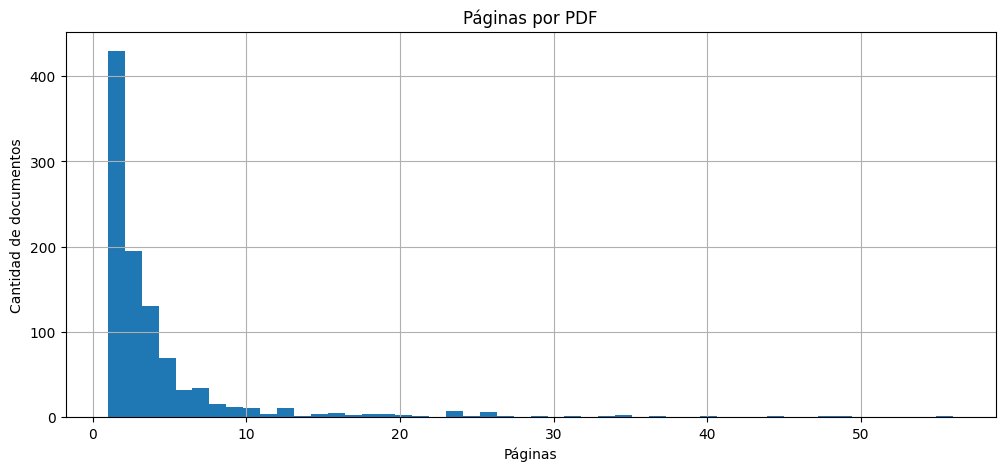

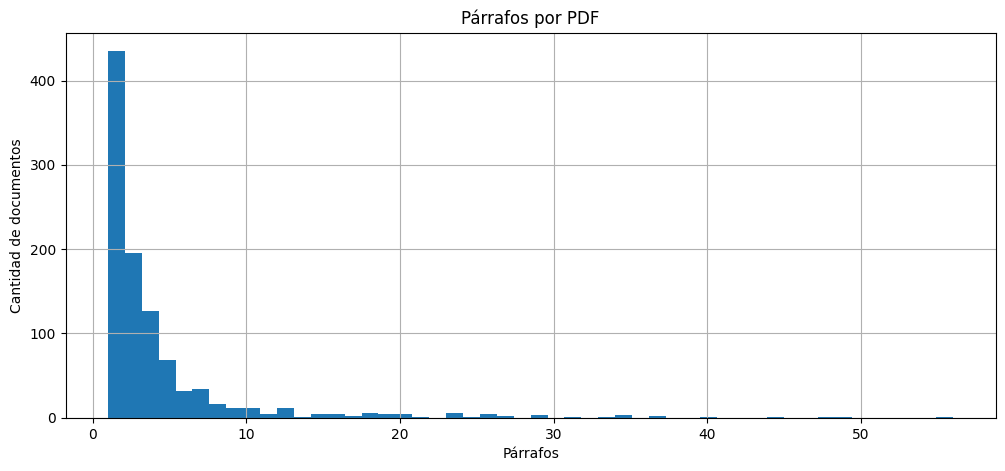

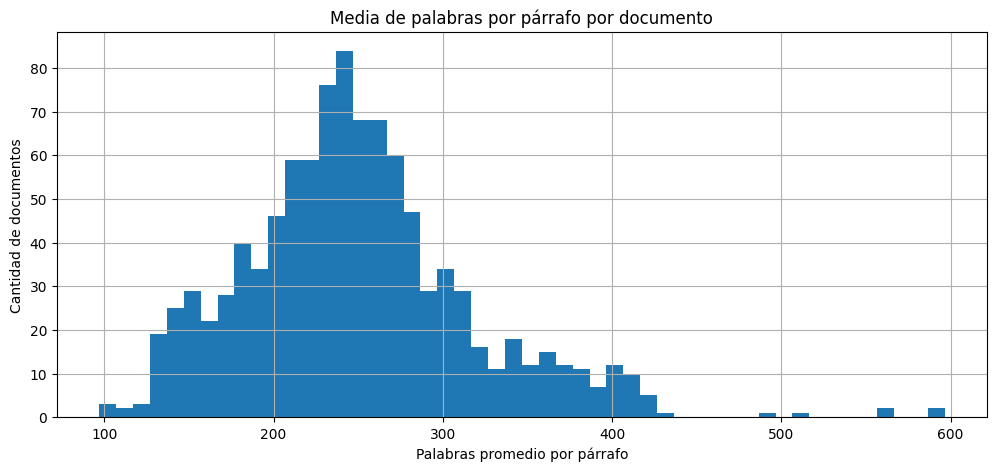

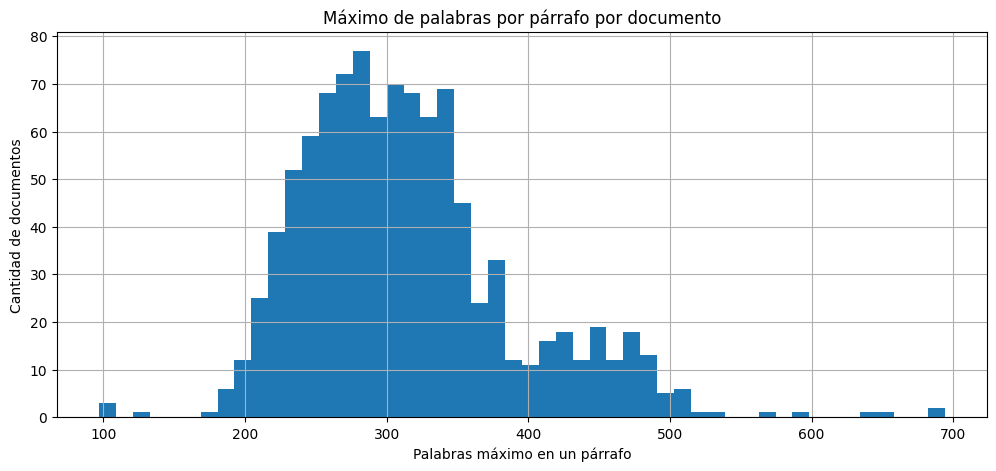

In [ ]:


# Pages per PDF
plt.figure(figsize=(12,5))
stats_df["pages"].hist(bins=50)
plt.title("Páginas por PDF")
plt.xlabel("Páginas")
plt.ylabel("Cantidad de documentos")
plt.show()

# Paragraphs per PDF
plt.figure(figsize=(12,5))
stats_df["paragraphs"].hist(bins=50)
plt.title("Párrafos por PDF")
plt.xlabel("Párrafos")
plt.ylabel("Cantidad de documentos")
plt.show()

# Words per paragraph (global distribution)
plt.figure(figsize=(12,5))
stats_df["mean_words_per_paragraph"].hist(bins=50)
plt.title("Media de palabras por párrafo por documento")
plt.xlabel("Palabras promedio por párrafo")
plt.ylabel("Cantidad de documentos")
plt.show()

plt.figure(figsize=(12,5))
stats_df["max_words_per_paragraph"].hist(bins=50)
plt.title("Máximo de palabras por párrafo por documento")
plt.xlabel("Palabras máximo en un párrafo")
plt.ylabel("Cantidad de documentos")
plt.show()
